In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic-prediction-scc-study-group/titanic_train.csv
/kaggle/input/competitions/titanic-prediction-scc-study-group/sample submission.csv
/kaggle/input/competitions/titanic-prediction-scc-study-group/titanic_test.csv


Titanic Survival Prediction using Random Forest

This project predicts passenger survival on the Titanic dataset using Machine Learning. Data preprocessing, feature engineering, model training, and evaluation techniques were applied to achieve an accuracy of approximately 79%.

In [2]:
# Import pandas library and load the Titanic dataset
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/competitions/titanic-prediction-scc-study-group/titanic_train.csv'
)

df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S,1
1,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S,0
2,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S,0
3,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,1
4,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S,1


In [3]:
# Display dataset information such as columns, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
 11  Survived     712 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 66.9+ KB


In [4]:
# Check the number of missing values in each column
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         2
Survived         0
dtype: int64

In [5]:
# Fill missing values in Age and Embarked columns
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
                    
df.isnull().sum()


PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Survived         0
Embarked_Q       0
Embarked_S       0
dtype: int64

In [6]:
# Convert Gender values into numerical format
df["Sex"] = df["Sex"].astype(str).str.strip().str.lower()

df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Survived,Embarked_Q,Embarked_S
0,693,3,"Lam, Mr. Ali",0,28.5,0,0,1601,56.4958,NaN,1,False,True
1,482,2,"Frost, Mr. Anthony Wood ""Archie""",0,28.5,0,0,239854,0.0000,NaN,0,False,True
2,528,1,"Farthing, Mr. John",0,28.5,0,0,PC 17483,221.7792,C95,0,False,True
3,856,3,"Aks, Mrs. Sam (Leah Rosen)",1,18.0,0,1,392091,9.3500,NaN,1,False,True
4,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",1,31.0,1,1,C.A. 31921,26.2500,NaN,1,False,True


In [7]:
# Select input features and target variable
x = df[["Pclass", "Sex", "Age","Fare","Embarked_Q","Embarked_S"]]
y = df["Survived"]

In [8]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Train a Random Forest Classifier model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
# Evaluate model performance using accuracy score
accuracy = model.score(x_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.7902097902097902


In [11]:
# Identify the most important features used by the model

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
    
})

importance = importance.sort_values("Importance", ascending=False)
print(importance)

      Feature  Importance
3        Fare    0.314897
2         Age    0.281329
1         Sex    0.272760
0      Pclass    0.093890
5  Embarked_S    0.027069
4  Embarked_Q    0.010055


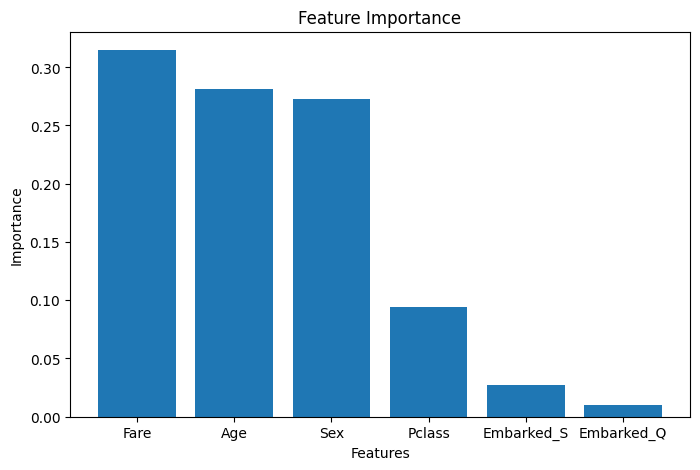

In [12]:
# Visualize feature importance using a bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [13]:
# Generate confusion matrix to evaluate prediction performance
from sklearn.metrics import confusion_matrix

y_pred = model.predict(x_test)
 
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[74 10]
 [20 39]]


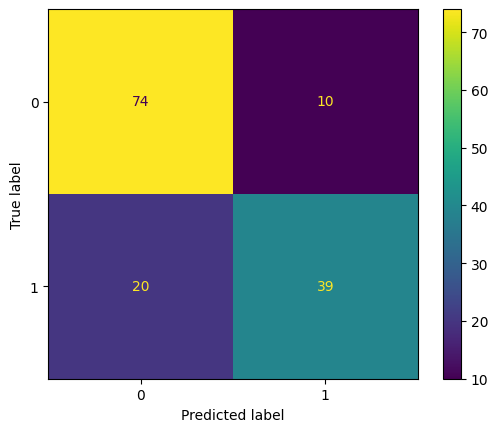

In [14]:
# Display confusion matrix as a graphical visualization
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()
